In [1]:
import pickle
import networkx as nx
import numpy as np
from disqco.drawing.mpl_drawing import draw_partitioned_graph_nx as draw_partitioned_graph
from disqco.parti.nx_partitioning import *
from disqco.parti.FM.FM_main_nx import calculate_cut_size
import time



partitioning_functions = {
    'BFS': breadth_first_search_partitioning,
    'Contraction': contraction_partitioning,
    'Spectral': spectral_bisection,
    'FM': fm_partitioning,
    'KL': kernighan_lin
}

In [ ]:
graph_names = ['H64_l1', 'H64_l2', 'H64_l3', 'H64_l4', 'H144_l1', 'H144_l2', 'H144_l3', 'H144_l4', 'H400_l1', 'H400_l2', 'H400_l3', 'H400_l4']
# graph_names = ['H64_l1', 'H64_l2', 'H64_l3', 'H64_l4']
qpu_sizes = (56,)

graph_results = {}
for graph_name in graph_names:
    with open(f'graphs/graph_{graph_name}.pkl', 'rb') as f:
        graph = pickle.load(f)
    

    for u, v in graph.edges():
        if 'weight' not in graph[u][v]:
            graph[u][v]['weight'] = 1

    results = {}
    for name, func in partitioning_functions.items():

        print(f'\n{name} Partitioning:')
        print('---------------------')
        print(f'Max QPU capacity: {qpu_sizes[0]}')
        print(f'Max allowed partition size: {int((2/3)*qpu_sizes[0])}')
        start = time.time()
        assignment = func(graph, max_capacity=int((2/3)*qpu_sizes[0]))
        end = time.time()
        cut = calculate_cut_size(graph, assignment)
        partition_counts = np.bincount(assignment)

        results[name] = {
            'cut_size': cut,
            'partition_counts': partition_counts,
            'num_partitions': len(partition_counts),
            'time_taken': end - start
        }

        print(f"Cut size: {cut}")
        print(f"Partition counts: {partition_counts}")
        print(f'Number of partitions: {len(partition_counts)}')    


    combined_workflows = {'BFS/FM', 'Contraction/FM', 'Spectral/FM'}

    for workflow in combined_workflows:
        print(f'\n{workflow} Partitioning:')
        print('---------------------')
        first, second = workflow.split('/')
        print(f'Max QPU capacity: {qpu_sizes[0]}')
        print(f'Max allowed partition size: {int((2/3)*qpu_sizes[0])}')
        start = time.time()
        intermediate_assignment = partitioning_functions[first](graph, max_capacity=int((2/3)*qpu_sizes[0]))
        assignment = partitioning_functions[second](graph, max_capacity=int((2/3)*qpu_sizes[0]), initial_assignment=intermediate_assignment)
        end = time.time()
        cut = calculate_cut_size(graph, assignment)
        partition_counts = np.bincount(assignment)


        results[workflow] = {
            'cut_size': cut,
            'partition_counts': partition_counts,
            'num_partitions': len(partition_counts),
            'time_taken': end - start
        }

        print(f"Cut size: {cut}")
        print(f"Partition counts: {partition_counts}")
        print(f'Number of partitions: {len(partition_counts)}')


    graph_results[graph_name] = results



BFS Partitioning:
---------------------
Max QPU capacity: 56
Max allowed partition size: 37
Cut size: 34
Partition counts: [38 26]
Number of partitions: 2
Squeezed Cut size: 34
Squeezed Partition counts: [38 26]

Contraction Partitioning:
---------------------
Max QPU capacity: 56
Max allowed partition size: 37
Cut size: 22
Partition counts: [32 32]
Number of partitions: 2
Squeezed Cut size: 22
Squeezed Partition counts: [32 32]

Spectral Partitioning:
---------------------
Max QPU capacity: 56
Max allowed partition size: 37
Cut size: 20
Partition counts: [32 32]
Number of partitions: 2
Squeezed Cut size: 20
Squeezed Partition counts: [32 32]

FM Partitioning:
---------------------
Max QPU capacity: 56
Max allowed partition size: 37
Cut size: 17
Partition counts: [27 37]
Number of partitions: 2
Squeezed Cut size: 17
Squeezed Partition counts: [27 37]

KL Partitioning:
---------------------
Max QPU capacity: 56
Max allowed partition size: 37
Cut size: 18
Partition counts: [32 32]
Numbe

KeyboardInterrupt: 

In [ ]:
# Plot results
cut_sizes = {name: [] for name in (partitioning_functions.keys() | combined_workflows)}
times = {name: [] for name in (partitioning_functions.keys() | combined_workflows)}
partitions_used = {name: [] for name in (partitioning_functions.keys() | combined_workflows)}

for graph_name, results in graph_results.items():
    print(f'\nResults for graph: {graph_name}')
    for method, data in results.items():
        print(f"\nMethod: {method}")
        print(f"Cut size: {data['cut_size']}")
        print(f"Partition counts: {data['partition_counts']}")
        print(f'Number of partitions: {data["num_partitions"]}')
        print(f'Time taken: {data["time_taken"]:.4f} seconds')

    # Store cut sizes for each method
    for method, data in results.items():
        cut_sizes[method].append(data['cut_size'])
        times[method].append(data['time_taken'])
        partitions_used[method].append(data['num_partitions'])




Results for graph: H64_l1

Method: BFS
Cut size: 34
Partition counts: [38 26]
Number of partitions: 2
Time taken: 0.0010 seconds

Method: Contraction
Cut size: 22
Partition counts: [32 32]
Number of partitions: 2
Time taken: 0.0157 seconds

Method: Spectral
Cut size: 18
Partition counts: [32 32]
Number of partitions: 2
Time taken: 0.0060 seconds

Method: FM
Cut size: 17
Partition counts: [27 37]
Number of partitions: 2
Time taken: 0.0000 seconds

Method: KL
Cut size: 16
Partition counts: [32 32]
Number of partitions: 2
Time taken: 0.0000 seconds

Method: BFS/FM
Cut size: 16
Partition counts: [30 34]
Number of partitions: 2
Time taken: 0.0144 seconds

Method: Contraction/FM
Cut size: 18
Partition counts: [32 32]
Number of partitions: 2
Time taken: 0.0157 seconds

Method: Spectral/FM
Cut size: 16
Partition counts: [32 32]
Number of partitions: 2
Time taken: 0.0180 seconds

Results for graph: H64_l2

Method: BFS
Cut size: 112
Partition counts: [38 37 37 37 37 37 33]
Number of partitions:

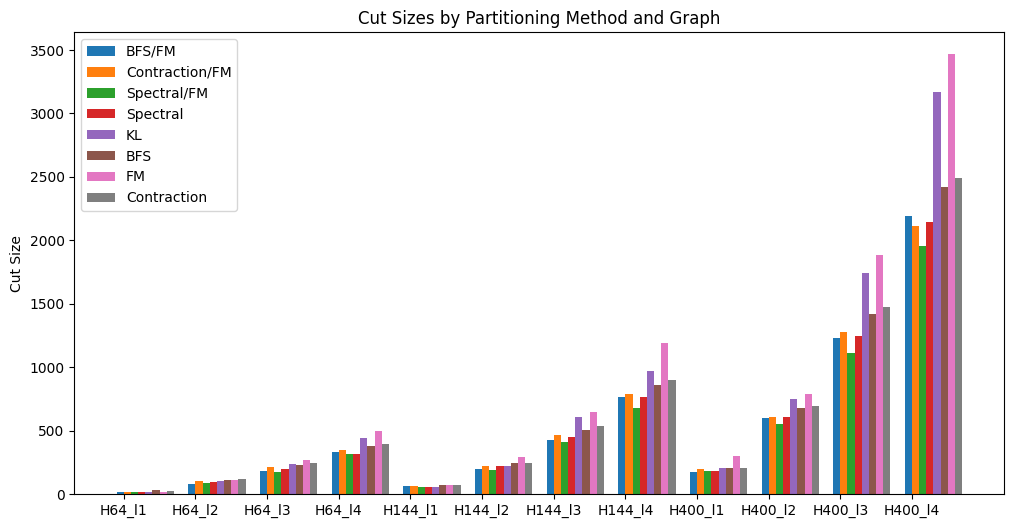

In [ ]:

import matplotlib.pyplot as plt

graph_names = list(graph_results.keys())
x = np.arange(len(graph_names))  # the label locations
width = 0.1  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, (method, sizes) in enumerate(cut_sizes.items()):
    ax.bar(x + i*width, sizes, width, label=method)
ax.set_ylabel('Cut Size')
ax.set_title('Cut Sizes by Partitioning Method and Graph')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(graph_names)
ax.legend()
plt.show()


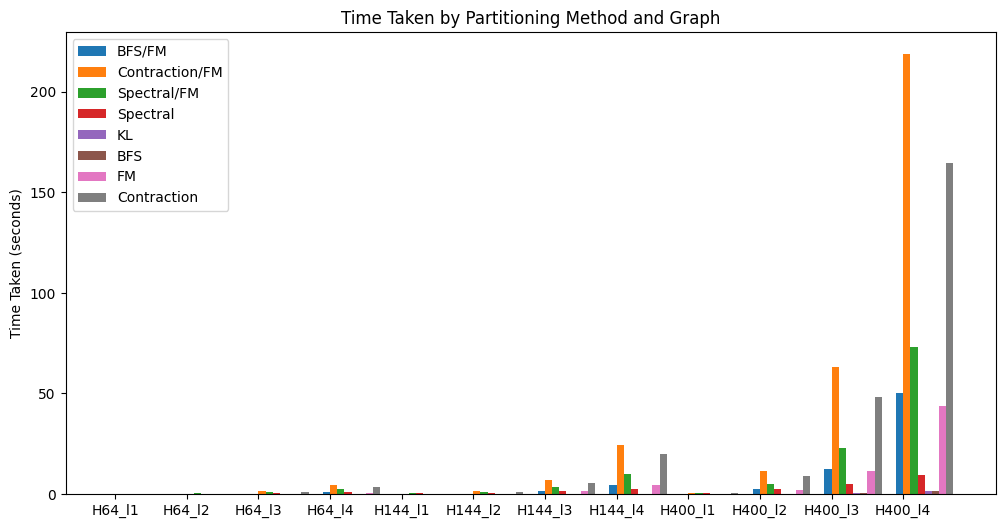

In [ ]:
import matplotlib.pyplot as plt

graph_names = list(graph_results.keys())
x = np.arange(len(graph_names))  # the label locations
width = 0.1  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, (method, sizes) in enumerate(times.items()):
    ax.bar(x + i*width, sizes, width, label=method)
ax.set_ylabel('Time Taken (seconds)')
ax.set_title('Time Taken by Partitioning Method and Graph')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(graph_names)
ax.legend()
plt.show()


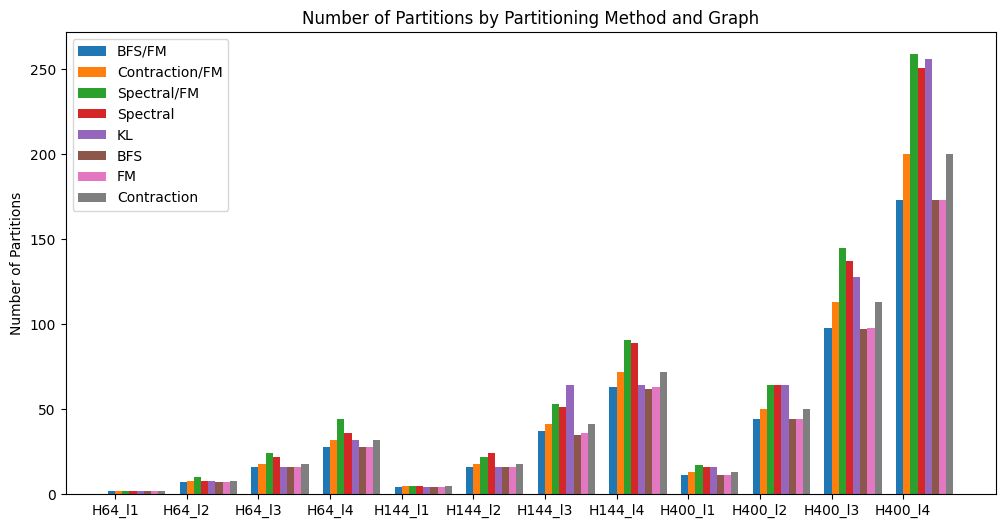

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(graph_names))  # the label locations
width = 0.1  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, (method, sizes) in enumerate(partitions_used.items()):
    ax.bar(x + i*width, sizes, width, label=method)
ax.set_ylabel('Number of Partitions')
ax.set_title('Number of Partitions by Partitioning Method and Graph')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(graph_names)
ax.legend()
plt.show()
